In [18]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

1. Eigenvalues of a large Hermitian matrix.

In [ ]:
M = 1; N = 5000;
eigs = random_matrix.init_gue_eigenvalues(M, N).flatten()

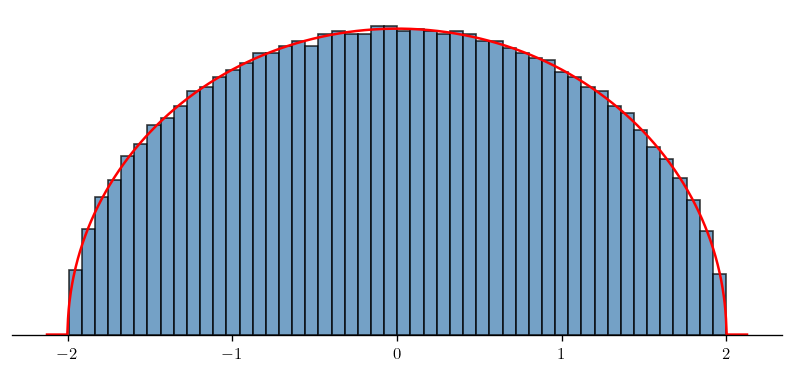

In [10]:
fig, ax = plt.subplots()
plotters.plot_hist(ax, eigs, num_bins = 50, potential_name = "quadratic")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])

plt.savefig("figures/eigs-random-N5000.pdf", format = "pdf", dpi = 120)
plt.show()

---

2. Unadjusted methods.

Tamed: $N=30$ and $N = 100$ for $dt = 1/N, 1/N^2$, empirical densities and distance metrics.

In [ ]:
importlib.reload(densities);
beta = 2.0; T = 10.0; M = 50; pot_name = "quartic"; num_bins = 50
grid = np.linspace(-2, 2, 1000); 

N = 100; init = random_matrix.init_gue_eigenvalues(M, N)
F_exact = densities.compute_exact_cdf(N, pot_name, grid)
dt = 1/(N**3/2); total_steps = int(T/dt); 

config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks"}

tamed_pipe_1a = simulate.get_pipeline("tamed", N = N, dt = dt, potential_type = pot_name, beta = beta)
trajectory_1a = simulate.simulate_dbm(init, total_steps, tamed_pipe_1a)
info_1a = simulate.analyse_trajectory(trajectory_1a, total_steps, **config)

dt = 1/(N**2); total_steps = int(T/dt); 
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks"}

tamed_pipe_1b = simulate.get_pipeline("tamed", N = N, dt = dt, potential_type = pot_name, beta = beta)
trajectory_1b = simulate.simulate_dbm(init, total_steps, tamed_pipe_1b)
info_1b = simulate.analyse_trajectory(trajectory_1b, total_steps, **config)

In [ ]:
importlib.reload(plotters);
fig, axes = plt.subplots(1, 2, figsize = (10, 3))
ax1, ax2 = axes

plotters.plot_hist(ax1, np.clip(info_1a["snapshots"], -2, 2), num_bins = num_bins, potential_name = pot_name)
plotters.plot_hist(ax2, np.clip(info_1b["snapshots"], -2, 2), num_bins = num_bins, potential_name = pot_name)

ax1.set_title(r"$\Delta t = 1/N\sqrt{N}$", fontsize = 15)
ax2.set_title(r"$\Delta t = 1/N^2$", fontsize = 15)

for ax in axes:
    ax.grid(False)

plt.show()

---


In [ ]:
# Implicit and implicit midpoint: use dt = 0.1 (O(1)) and track the distance metrics for large N (50, 100, 200)
# then compare this to when using 1/sqrt{N} and 1/N.

---
---
---
---
---